## Imports

In [2]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

from boed.priors.kernels import Gaussian, Matern32
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel, ColoredNoise
from boed.core import make_u0
from boed.pde.advection_diffusion import AdvectionDiffusion1D_CN
from boed.utils.observation import build_selection_matrices

## 1. Setup

In [3]:
np.random.seed(42)

N       = 100
dt      = 0.001
n_steps = 1000
sigma   = 0.05
lambda_ = 0.0

x_grid = np.linspace(0, 1, N + 2)[1:-1]

model    = AdvectionDiffusion1D_CN(N=N, dt=dt, diffusivity=0.02, velocity = 0.0)
u0_true  = make_u0(x_grid, "gaussian", center=0.25, width=0.07, amplitude=1.5)

kernel = Matern32(length_scale=.1, sigma=1.0)
prior  = GaussianProcessPrior(kernel, nx=N)
noise  = ColoredNoise(sigma_noise=sigma, correlation_length=20.3)

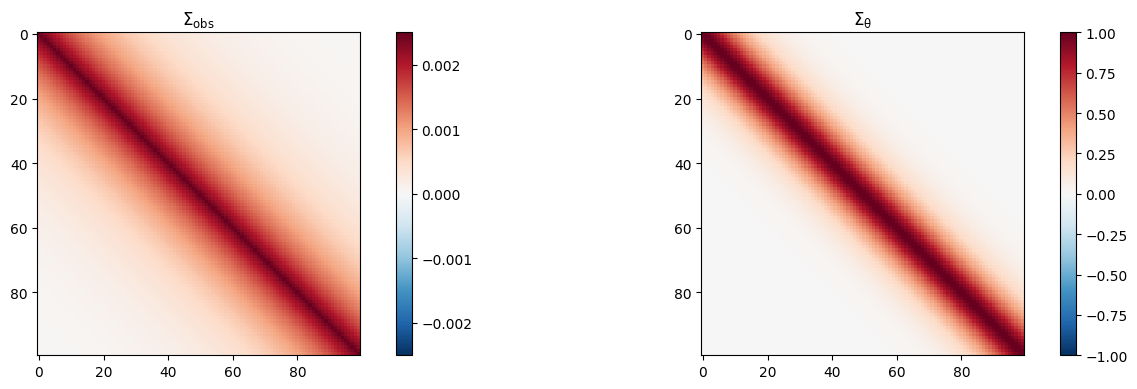

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, mat, title in zip(axes,
                           [noise.get_covariance(N), prior.Sigma],
                           [r"$\Sigma_{\rm obs}$",
                            r"$\Sigma_{\rm \theta}$"]):
    vmax = np.abs(mat).max()
    im   = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 2. Forward model

G : $\theta = u_0 \mapsto u(\cdot, T) \in \mathbb{R}^N$

In [5]:
def forward_model_matrix(pde_model, n_steps):
    """
    U_{n} = A^n U_0
    return A^n
    """
    An = pde_model.get_forward_operator(n_steps=n_steps)
    return An

G = forward_model_matrix(pde_model=model, n_steps=n_steps//10)
print(f"G(u0_true).shape = {G.shape}")

G(u0_true).shape = (100, 100)


## 3. Compute $\Sigma_{signal}$ de $\Sigma_Y$
## In this linear case, $\Sigma_{\rm signal} = \Sigma_Y$
$$\Sigma_Y = \Sigma_{\rm obs} + G \Sigma_{\theta} G^T$$

In [6]:
def compute_Sigma_Y(G, prior, Sigma_obs):
    """
    compute Sigma_Y = Sigma_obs + G \Sigma_theta G^T.

    Retourne
    --------
    Sigma_Y : array (m, m)
    """
    return Sigma_obs + G @ prior.Sigma @ G.T


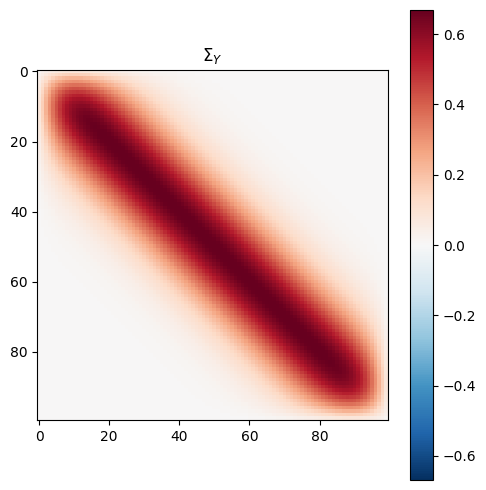

In [7]:
Sigma_Y = compute_Sigma_Y(G=G, prior=prior, Sigma_obs=noise.get_covariance(N))

fig, ax = plt.subplots(figsize=(5, 5))
vmax = np.abs(Sigma_Y).max()
im   = ax.imshow(Sigma_Y, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_title(r"$\Sigma_Y$")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 4. Estimateurs de l'EIG

### 4a. Borne supérieure analytique (BS)

$$\mathrm{EIG}_{\rm BS}(W) = \mathrm{EIG}(I) + 
\frac{1}{2}\log\frac{\det(W^\top \Sigma_{\rm signal} W)}{\det(W^\top \Sigma_{\rm obs} W)}
- \frac{1}{2}\log\frac{\det(\Sigma_{\rm signal})}{\det(\Sigma_{\rm obs})}$$

In [8]:
def eig_BS(Sigma_signal, Sigma_obs, W):
    """
    Borne superieure de l'EIG basee sur Sigma_signal.

    Parametres
    ----------
    Sigma_signal : array (m, m)
    Sigma_obs    : array (m, m)
    W            : array (m, s)   matrice de selection des capteurs

    Retourne
    --------
    float
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_obs.shape[0])
    return 0.5 * (log_ratio(Sigma_signal, Sigma_obs, W)
                  - log_ratio(Sigma_signal, Sigma_obs, eye))

### 4b. Estimateur direct sur $\Sigma_Y$ (BI)

$$\mathrm{EIG}_{\rm BI}(W) = \mathrm{EIG}(I) + 
\frac{1}{2}\log\frac{\det(W^\top \Sigma_Y W)}{\det(W^\top \Sigma_{\rm obs} W)}
- \frac{1}{2}\log\frac{\det(\Sigma_Y)}{\det(\Sigma_{\rm obs})}$$

In [9]:
def eig_BI(Sigma_Y, Sigma_obs, W):
    """
    Estimateur de l'EIG base sur Sigma_Y empirique.
    Meme structure que eig_BS, remplace Sigma_signal par Sigma_Y.
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_obs.shape[0])
    return 0.5 * (log_ratio(Sigma_Y, Sigma_obs, W)
                  - log_ratio(Sigma_Y, Sigma_obs, eye))

## 8. Comparaison des estimateurs

In [10]:
def greedy_maximize_LB(Sigma_Y, Sigma_obs, n_sensors):
    """
    Maximise eig_BI(W) par greedy forward.
    Critere : log|Sigma_Y[S,S]| - log|Sigma_obs[S,S]|
    """
    N         = Sigma_Y.shape[0]
    selected  = []
    remaining = list(range(N))

    for step in range(n_sensors):
        best_idx, best_score = None, -np.inf

        for idx in remaining:
            S     = selected + [idx]
            ix    = np.ix_(S, S)
            score = (la.slogdet(Sigma_Y[ix])[1]
                   - la.slogdet(Sigma_obs[ix])[1])
            if score > best_score:
                best_score = score
                best_idx   = idx

        selected.append(best_idx)
        remaining.remove(best_idx)
        # print(f"  step {step+1}/{n_sensors} — capteur {best_idx} ajouté, score={best_score:.4f}")

    return np.array(selected)

In [11]:
from scipy.linalg import eigh

def optimal_W_continuous(Sigma_Y, Sigma_obs, s):
    """
    Colonnes de W* = vecteurs propres generalises de (Sigma_Y, Sigma_obs)
    associes aux s plus grandes valeurs propres.

    Retourne
    --------
    W      : array (N, s)
    eigvals : array (s,)  valeurs propres en ordre decroissant
    """
    # eigh resout A v = lambda B v pour A, B symetriques
    # retourne valeurs propres en ordre croissant
    eigvals, eigvecs = eigh(Sigma_Y, Sigma_obs)

    # On prend les s plus grandes
    idx     = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    return eigvecs[:, :s], eigvals[:s]


def eig_continuous(Sigma_Y, Sigma_obs, n_sensors):
    """
    Valeur optimale du critere LB pour W continu.
    = somme des log des s plus grandes valeurs propres.
    """
    _, eigvals = optimal_W_continuous(Sigma_Y, Sigma_obs, n_sensors)
    return 0.5 * np.sum(np.log(eigvals))

In [12]:
W_opt, eigvals = optimal_W_continuous(Sigma_Y, noise.get_covariance(N), s=10)

lb_continuous = eig_continuous(Sigma_Y, noise.get_covariance(N), n_sensors=10)
#lb_greedy     = eig_BI(Sigma_Y, Sigma_obs, W_greedy)

print(f"LB continu (optimal) : {lb_continuous:.4f}")
#print(f"LB greedy (binaire)  : {lb_greedy:.4f}")
#print(f"Suboptimalité greedy : {lb_continuous - lb_greedy:.4f}")

LB continu (optimal) : 24.8515


In [13]:
sensors = [5,10,15,20,25,30,35,40,50,60,70]
DLB, DUB, gap = [], [], []
Sigma_signal = Sigma_Y.copy()
for budget in sensors: 
    # Matrice de selection aleatoire
    indices = greedy_maximize_LB(Sigma_Y=Sigma_Y, Sigma_obs=noise.get_covariance(N), n_sensors=budget)

    W_opt, _ = build_selection_matrices(N, indices)
    lb = eig_BI(Sigma_Y, noise.get_covariance(N), W_opt)
    ub = eig_BS(Sigma_signal, noise.get_covariance(N), W_opt)
    DLB.append(lb), DUB.append(ub)
    print("*"*15)
    print(f"LB = {lb:.4f},  UB = {ub:.4f},  gap = {ub - lb:.4f}")


***************
LB = -12.8304,  UB = -12.8304,  gap = 0.0000
***************
LB = -4.2515,  UB = -4.2515,  gap = 0.0000
***************
LB = -1.6528,  UB = -1.6528,  gap = 0.0000
***************
LB = -0.8616,  UB = -0.8616,  gap = 0.0000
***************
LB = -0.5926,  UB = -0.5926,  gap = 0.0000
***************
LB = -0.3780,  UB = -0.3780,  gap = 0.0000
***************
LB = -0.2375,  UB = -0.2375,  gap = 0.0000
***************
LB = -0.1836,  UB = -0.1836,  gap = 0.0000
***************
LB = -0.1288,  UB = -0.1288,  gap = 0.0000
***************
LB = -0.0799,  UB = -0.0799,  gap = 0.0000
***************
LB = -0.0489,  UB = -0.0489,  gap = 0.0000


/tmp/ipykernel_104465/3608254274.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


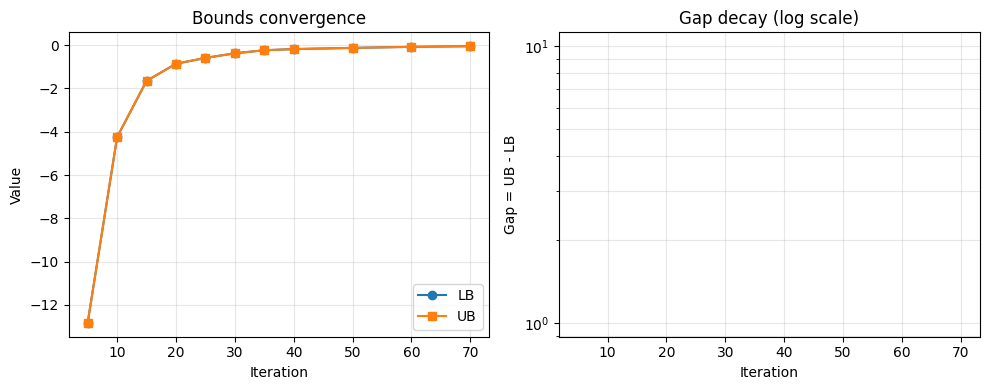

In [14]:
import numpy as np
import matplotlib.pyplot as plt

LB = np.array(DLB)

UB = np.array(DUB)

gap = UB - LB


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panneau gauche : bornes
axes[0].plot(sensors, LB, marker='o', label='LB')
axes[0].plot(sensors, UB, marker='s', label='UB')
axes[0].fill_between(sensors, LB, UB, alpha=0.2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Value")
axes[0].set_title("Bounds convergence")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panneau droit : gap
axes[1].semilogy(sensors, gap, marker='d')
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Gap = UB - LB")
axes[1].set_title("Gap decay (log scale)")
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_104465/3619679051.py:24: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


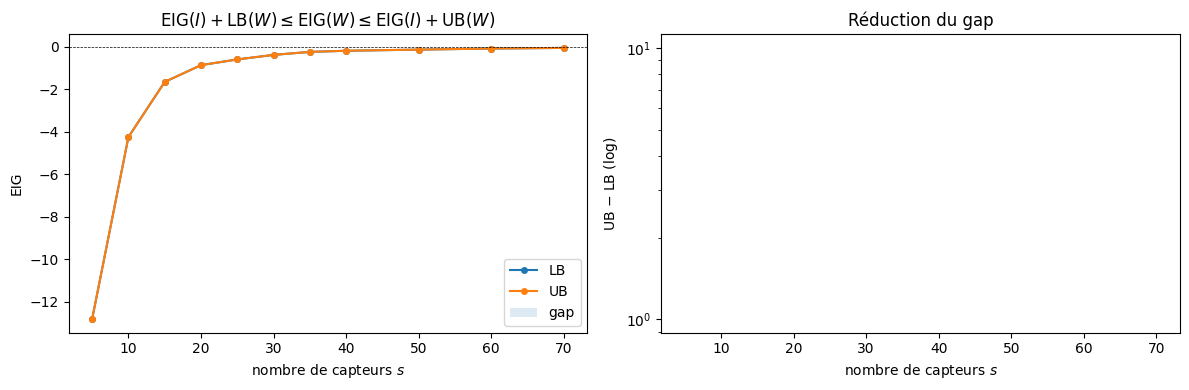

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
LB = np.array(DLB)

UB = np.array(DUB)

gap = UB - LB

# ── Gauche : LB, UB et intervalle
ax1.plot(sensors, LB,  label="LB", marker='o', markersize=4)
ax1.plot(sensors, UB,  label="UB", marker='o', markersize=4)
ax1.fill_between(sensors, LB, UB, alpha=0.15, label="gap")
ax1.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax1.set_xlabel("nombre de capteurs $s$")
ax1.set_ylabel("EIG")
ax1.set_title(r"$\mathrm{EIG}(I) + \mathrm{LB}(W) \leq \mathrm{EIG}(W) \leq \mathrm{EIG}(I) + \mathrm{UB}(W)$")
ax1.legend()

# ── Droite : gap seul en log
ax2.semilogy(sensors, gap, color='tomato', marker='o', markersize=4)
ax2.set_xlabel("nombre de capteurs $s$")
ax2.set_ylabel("UB $-$ LB (log)")
ax2.set_title("Réduction du gap")

plt.tight_layout()
plt.savefig("eig_bounds.png", dpi=150)
plt.show()